In [1]:
import kagglehub
sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-gaussian-filtered')

print('Data source import complete.')
print(sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path)

Data source import complete.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [2]:
import os
import shutil

# Répertoires
source_dir = '/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images'
target_dir = '/content/images'

# Dictionnaire de renommage
rename_dict = {
    'Mild': '1_Mild',
    'Moderate': '2_Moderate',
    'No_DR': '0_No_DR',
    'Proliferate_DR': '4_Proliferate_DR',
    'Severe': '3_Severe'
}

# Créer le dossier cible
os.makedirs(target_dir, exist_ok=True)

# Copier et renommer les dossiers
for old_name, new_name in rename_dict.items():
    old_path = os.path.join(source_dir, old_name)
    new_path = os.path.join(target_dir, new_name)

    if os.path.exists(old_path):
        shutil.copytree(old_path, new_path)
        print(f'Copié et renommé : {old_name} → {new_name}')
    else:
        print(f'Dossier introuvable : {old_path}')


Copié et renommé : Mild → 1_Mild
Copié et renommé : Moderate → 2_Moderate
Copié et renommé : No_DR → 0_No_DR
Copié et renommé : Proliferate_DR → 4_Proliferate_DR
Copié et renommé : Severe → 3_Severe


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/train.csv')

diagnosis_dict = {
    0: '0_No_DR',
    1: '1_Mild',
    2: '2_Moderate',
    3: '3_Severe',
    4: '4_Proliferate_DR',
}

path = '/content/images'
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
#df['filename'] = path + '/' + df['type'] + '/' + df['id_code'] + '.png'
df.head()

,id_code,diagnosis,type
0,000c1434d8d7,2,2_Moderate
1,001639a390f0,4,4_Proliferate_DR
2,0024cdab0c1e,1,1_Mild
3,002c21358ce6,0,0_No_DR
4,005b95c28852,0,0_No_DR


<Axes: ylabel='type'>

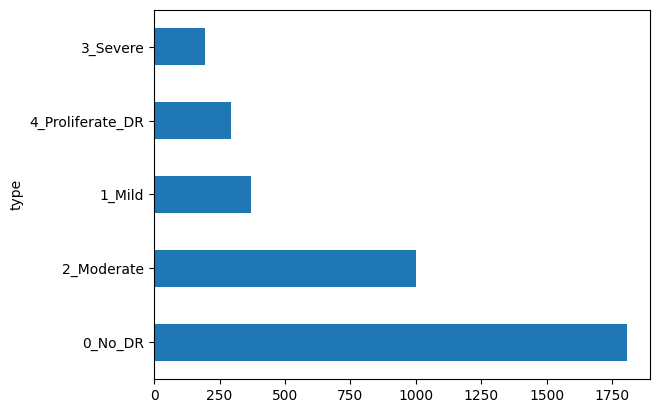

In [5]:
df['type'].value_counts().plot(kind='barh')

In [6]:
sdir=r'/content/images'
classlist=os.listdir(sdir)
filepaths=[]
labels=[]
for klass in classlist:
    classpath=os.path.join(sdir,klass)
    if os.path.isdir(classpath):
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
Fseries=pd.Series(filepaths, name='filepaths')
Lseries=pd.Series(labels, name='labels')
df=pd.concat([Fseries, Lseries], axis=1)
print (df.head())
print('df length: ', len(df))
print (df['labels'].value_counts())

                                  filepaths   labels
0  /content/images/0_No_DR/65f5d2a6eb7e.png  0_No_DR
1  /content/images/0_No_DR/4c635a01593d.png  0_No_DR
2  /content/images/0_No_DR/0a902c80d5da.png  0_No_DR
3  /content/images/0_No_DR/d6803e467592.png  0_No_DR
4  /content/images/0_No_DR/224c14366e11.png  0_No_DR
df length:  3662
labels
0_No_DR             1805
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64


In [7]:
sample_list=[]
max_size= 1500
groups=df.groupby('labels')
for label in df['labels'].unique():
    group=groups.get_group(label)
    sample_count=len(group)
    if sample_count> max_size:
        samples=group.sample(max_size, replace=False, weights=None, random_state=123, axis=0).reset_index(drop=True)
    else:
        samples=group.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)
    sample_list.append(samples)
df=pd.concat(sample_list, axis=0).reset_index(drop=True)
print (len(df))
print (df['labels'].value_counts())

3357
labels
0_No_DR             1500
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64


In [8]:
working_dir=r'./'
aug_dir=os.path.join(working_dir, 'aug')
if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
os.mkdir(aug_dir)
for label in df['labels'].unique():
    dir_path=os.path.join(aug_dir,label)
    os.mkdir(dir_path)
print(os.listdir(aug_dir))

['0_No_DR', '4_Proliferate_DR', '1_Mild', '3_Severe', '2_Moderate']


In [9]:
target=1500 # set the target count for each class in df
gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,
                              height_shift_range=.2, zoom_range=.2)
groups=df.groupby('labels') # group by class
for label in df['labels'].unique():  # for every class
    group=groups.get_group(label)  # a dataframe holding only rows with the specified label
    sample_count=len(group)   # determine how many samples there are in this class
    if sample_count< target: # if the class has less than target number of images
        aug_img_count=0
        delta=target-sample_count  # number of augmented images to create
        target_dir=os.path.join(aug_dir, label)  # define where to write the images
        aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=(224,224), class_mode=None,
                                        batch_size=1, shuffle=False, save_to_dir=target_dir, save_prefix='aug-',
                                        save_format='png')
        while aug_img_count<delta:
            images=next(aug_gen)
            aug_img_count += len(images)

Found 295 validated image filenames.
Found 370 validated image filenames.
Found 193 validated image filenames.
Found 999 validated image filenames.


In [10]:
aug=r'./aug'
auglist=os.listdir(aug)
print (auglist)
for klass in auglist:
    classpath=os.path.join(aug, klass)
    flist=os.listdir(classpath)
    print('class: ', klass, '  file count: ', len(flist))

['0_No_DR', '4_Proliferate_DR', '1_Mild', '3_Severe', '2_Moderate']
class:  0_No_DR   file count:  0
class:  4_Proliferate_DR   file count:  1205
class:  1_Mild   file count:  1130
class:  3_Severe   file count:  1307
class:  2_Moderate   file count:  501


In [11]:
aug_fpaths=[]
aug_labels=[]
classlist=os.listdir(aug_dir)
for klass in classlist:
    classpath=os.path.join(aug_dir, klass)
    flist=os.listdir(classpath)
    for f in flist:
        fpath=os.path.join(classpath,f)
        aug_fpaths.append(fpath)
        aug_labels.append(klass)
Fseries=pd.Series(aug_fpaths, name='filepaths')
Lseries=pd.Series(aug_labels, name='labels')
aug_df=pd.concat([Fseries, Lseries], axis=1)
ndf=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
#ndf=df.sample(frac=1.0, replace=False, random_state=123, axis=0).reset_index(drop=True)


print (df['labels'].value_counts())
print(aug_df['labels'].value_counts())
print (ndf['labels'].value_counts())

labels
0_No_DR             1500
2_Moderate           999
1_Mild               370
4_Proliferate_DR     295
3_Severe             193
Name: count, dtype: int64
labels
3_Severe            1307
4_Proliferate_DR    1205
1_Mild              1130
2_Moderate           501
Name: count, dtype: int64
labels
0_No_DR             1500
4_Proliferate_DR    1500
1_Mild              1500
3_Severe            1500
2_Moderate          1500
Name: count, dtype: int64


<Axes: ylabel='labels'>

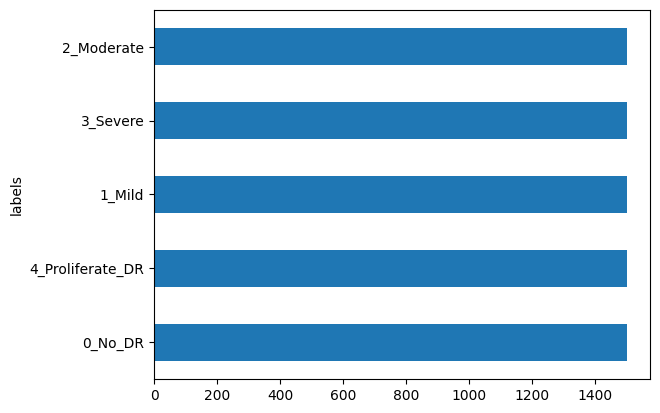

In [12]:
ndf['labels'].value_counts().plot(kind='barh')

In [13]:
ndf.head()

,filepaths,labels
0,/content/images/0_No_DR/de18071c36e6.png,0_No_DR
1,/content/images/0_No_DR/668a319c2d23.png,0_No_DR
2,/content/images/0_No_DR/3b5dffe159b6.png,0_No_DR
3,/content/images/0_No_DR/d99dd99be001.png,0_No_DR
4,/content/images/0_No_DR/ee3fe7809e6a.png,0_No_DR


In [14]:
train_intermediate, test = train_test_split(ndf, test_size = 0.1, stratify = ndf['labels'])
train, val = train_test_split(train_intermediate, test_size = 0.1 / (1 - 0.1), stratify = train_intermediate['labels'])

print("Train shape: ", train.shape)
print("Test shape: ",test.shape)
print("Valid shape: ", val.shape)

print(train['labels'].value_counts(), '\n')
print(test['labels'].value_counts(), '\n')
print(val['labels'].value_counts(), '\n')

Train shape:  (6000, 2)
Test shape:  (750, 2)
Valid shape:  (750, 2)
labels
2_Moderate          1200
4_Proliferate_DR    1200
0_No_DR             1200
1_Mild              1200
3_Severe            1200
Name: count, dtype: int64 

labels
4_Proliferate_DR    150
3_Severe            150
0_No_DR             150
2_Moderate          150
1_Mild              150
Name: count, dtype: int64 

labels
4_Proliferate_DR    150
1_Mild              150
3_Severe            150
2_Moderate          150
0_No_DR             150
Name: count, dtype: int64 



In [15]:
datagen = ImageDataGenerator(rescale=1./255)

train_batches = datagen.flow_from_dataframe(
    dataframe=train,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32
)

val_batches = datagen.flow_from_dataframe(
    dataframe=val,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32)

test_batches = datagen.flow_from_dataframe(
    dataframe=test,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    batch_size=32)

Found 6000 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.


In [31]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

resnet = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = tf.keras.Sequential()
model.add(resnet)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(5, activation='sigmoid'))

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=Adam(0.0001,decay=1e-6),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 21,778,597 (83.08 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [32]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_batches,
                    epochs=50,
                    validation_data=val_batches,
                    callbacks=[reduce_lr, early_stop]
                    )

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 163s 474ms/step - accuracy: 0.4945 - loss: 1.2047 - val_accuracy: 0.5507 - val_loss: 1.3414 - learning_rate: 1.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 246ms/step - accuracy: 0.7579 - loss: 0.6492 - val_accuracy: 0.7293 - val_loss: 0.7513 - learning_rate: 1.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 245ms/step - accuracy: 0.8771 - loss: 0.3214 - val_accuracy: 0.7707 - val_loss: 0.7021 - learning_rate: 1.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 245ms/step - accuracy: 0.9340 - loss: 0.1985 - val_accuracy: 0.7893 - val_loss: 0.6836 - learning_rate: 1.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 244ms/step - accuracy: 0.9508 - loss: 0.1465 - val_accuracy: 0.7760 - val_loss: 0.7344 - learning_rate: 1.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 245ms/step - accuracy: 0.9676 - loss: 0.1032 - val_accuracy: 0.7893 - val_loss: 0.7393 - learning_rate: 1.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 2

In [33]:
model.save('InceptionV3_model.h5')

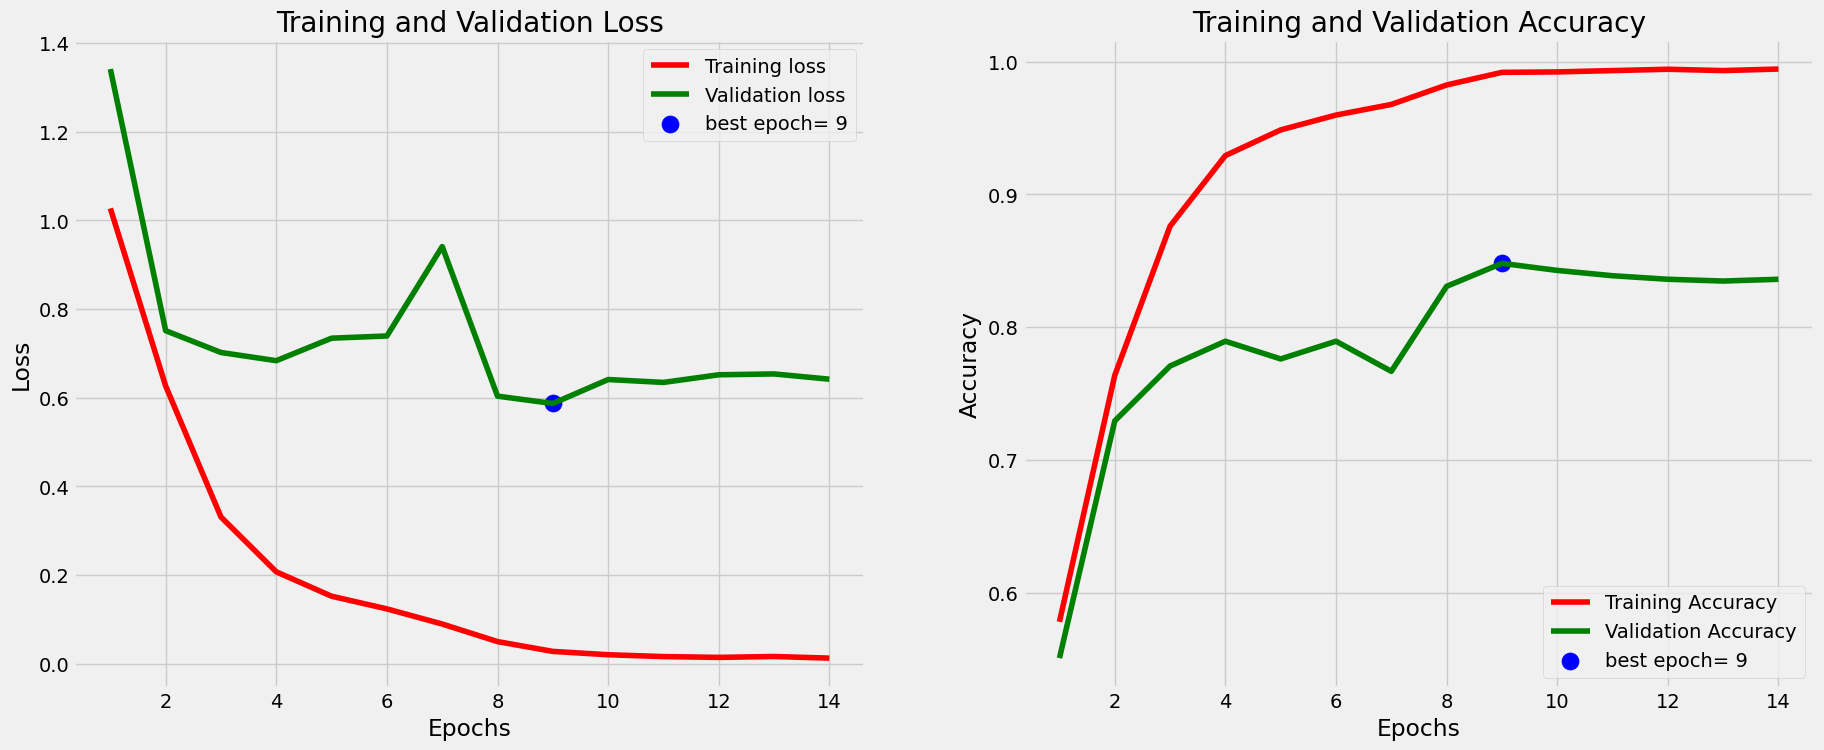

In [34]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [35]:
train_score = model.evaluate(train_batches, verbose= 1)
valid_score = model.evaluate(val_batches, verbose= 1)
test_score = model.evaluate(test_batches, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.9949 - loss: 0.0091
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.8560 - loss: 0.5200
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8467 - loss: 0.6330
Train Loss:  0.008885202929377556
Train Accuracy:  0.9956666827201843
--------------------
Validation Loss:  0.587077796459198
Validation Accuracy:  0.8479999899864197
--------------------
Test Loss:  0.6533306837081909
Test Accuracy:  0.8399999737739563


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step


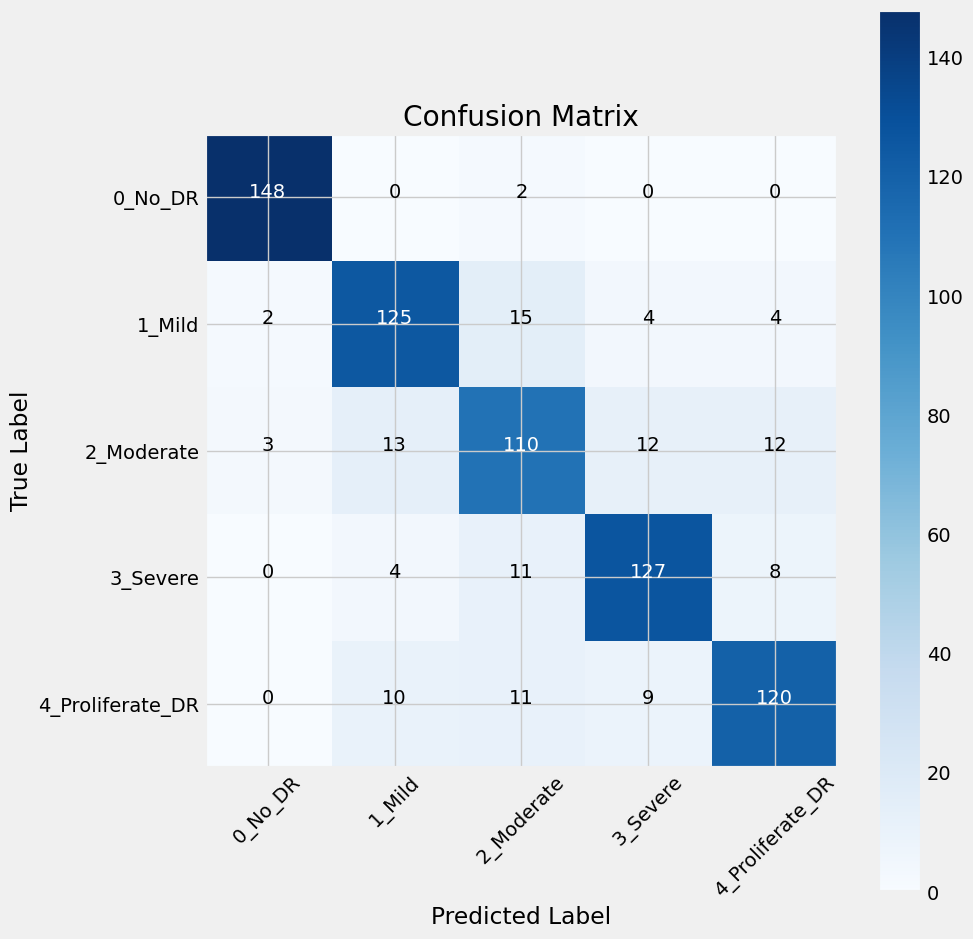

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

preds = model.predict(test_batches, steps=len(test_batches))
y_pred = np.argmax(preds, axis=1)

g_dict = test_batches.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [37]:
# Classification report
print(classification_report(test_batches.classes, y_pred, target_names= classes))

                  precision    recall  f1-score   support

         0_No_DR       0.97      0.99      0.98       150
          1_Mild       0.82      0.83      0.83       150
      2_Moderate       0.74      0.73      0.74       150
        3_Severe       0.84      0.85      0.84       150
4_Proliferate_DR       0.83      0.80      0.82       150

        accuracy                           0.84       750
       macro avg       0.84      0.84      0.84       750
    weighted avg       0.84      0.84      0.84       750

